# Getting started with GRASS using WSL

Brendan Harmon  
2026-08-28

This is a very short introduction to using GRASS on [Windows Subsystem
for Linux](https://learn.microsoft.com/en-us/windows/wsl/). This is the
recommended way to use GRASS as a Python library on Windows, because
Python and GRASS are more seamlessly integrated with Unix-like operating
systems.

## Windows Terminal

You will use shell scripting with Bash in a terminal to set up GRASS in
a Conda environment. We recommend using the new Windows Terminal which
has been included in Windows 11 releases since 2022. If you have an
older version of Windows 10 or 11, then install [Windows
Terminal](https://apps.microsoft.com/detail/9n0dx20hk701?hl=en-US&gl=US)
from the Microsoft Store. With Windows Terminal you can open new tabs
for different command line shells such as Powershell. Once you have
installed Windows System for Linux, you will be be able to open an
Ubuntu tab too.

> **Setting up Windows Terminal**
>
> More more information, see the official guide to [install and get
> started setting up Windows
> Terminal](https://learn.microsoft.com/en-us/windows/terminal/install).

## Windows Subsystem for Linux

With Windows Subsystem for Linux you can cleanly install the Linux build
of GRASS in a Conda environment on Windows. With this build of GRASS you
will be able to install hundreds of addon tools, have much faster
multiprocessing, and easier scripting in Python. Let’s get started. Open
the Windows start menu, type `terminal`, and right click on Terminal’s
icon to run as an administrator. By default Terminal will open a
PowerShell tab. Run the following command in this administrator’s
PowerShell tab to install Windows Subsystem for Linux and Ubuntu. Once
the installation is complete, restart your computer.

``` {bash}
wsl --install
```

> **Setting up WSL**
>
> More more information, see the official guide to [set up a WSL
> development
> environment](https://learn.microsoft.com/en-us/windows/wsl/setup/environment).

## Ubuntu

After you have restarted your computer, open an Ubuntu shell in Windows
Terminal. To do this, you can search for Terminal via the Windows start
menu and then select Ubuntu as your shell. If you already have Terminal
open, click on the dropdown menu beside the top of the tab and pick
Ubuntu to open that shell in a new tab. The hotkey for should be
`Ctrl + Shift + 3`. In the dropdown menu, you can also find the settings
tab where you can set Ubuntu as the default shell if desired. Once you
open the Ubuntu shell for the first time, you will be prompted to enter
a new username and password.

## Python Distribution

Install [Miniforge](https://conda-forge.org/download/), a minimal Python
distribution with Conda for package management and conda-forge as the
default channel (<span class="nocase">conda-forge community</span>
2026). We recommend Miniforge because it is the easiest, cleanest way to
install the GRASS Conda Package. In the Ubuntu shell, download and run
the installation shell script. Answer `yes` when asked whether to
initialize Conda. After installing Miniforge, run the source command so
that your Ubuntu terminal finds the installation.

``` {bash}
sudo apt-get install wget
wget https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh
bash Miniforge3-$(uname)-$(uname -m).sh
source ~/.bashrc
```

> **Downloads**
>
> For Ubuntu distributions since 2025 `wget` has been replaced with
> `wcurl`.

## Environment

Now that Conda is installed, let’s use it to create an environment for
GRASS. We will install the GRASS, Jupyter Lab, and other useful Python
packages with all of their dependencies into this environment. In a
terminal, run [conda
create](https://docs.conda.io/projects/conda/en/stable/commands/create.html)
to create an environment named `grass`. Then use [conda
install](https://docs.conda.io/projects/conda/en/stable/commands/install.html)
to install the GRASS package. Next, run [conda
activate](https://docs.conda.io/projects/conda/en/stable/commands/activate.html)
to start the environment.

``` {bash}
conda create --name grass
conda activate grass
conda install grass jupyterlab requests folium ipyleaflet seaborn
```

You can do this with just one line of code:

``` {bash}
conda create -n grass grass jupyterlab requests folium ipyleaflet seaborn && conda activate grass
```

> **Other Conda distributions**
>
> If you use a Conda distribution other than Miniforge, you will need to
> specify the conda-forge channel when creating the environment with
> `-c conda-forge`. You may also need to override your default channel
> settings with `--override-channels` to prevent conflicts.

## Computational Notebook

Let’s try the newly installed GRASS Conda package in a Jupyter notebook.
We will use scripting to generate and visualize fractal terrain. Let’s
begin by launching Jupyter Lab from the terminal. This will open a new
Jupyter notebook in a web browser window.

``` {bash}
jupyter lab
```

### Start GRASS

To start a GRASS session, we need to define a project and its coordinate
reference system. Use
[grass.script.create_project](https://grass.osgeo.org/grass-stable/manuals/libpython/grass.script.html#grass.script.create_project)
to create a project named `fractal` without specifying a coordinate
system. By default this will create an unprojected Cartesian coordinate
system. Start the GRASS session with
[grass.jupyter.setup.init](https://grass.osgeo.org/grass-stable/manuals/libpython/grass.jupyter.html#grass.jupyter.setup.init).
Then instantiate a
[grass.tools](https://grass.osgeo.org/grass-stable/manuals/libpython/grass.tools.html#grass.tools.session_tools.Tools)
object so that you can call GRASS tools as Python functions.

> **GRASS Projects**
>
> Read more about
> [projects](https://grass.osgeo.org/grass-stable/manuals/grass_projects.html)
> in GRASS here.

In [1]:
# Import libraries
import os
import sys
import subprocess
from pathlib import Path

# Find GRASS Python packages
sys.path.append(
  subprocess.check_output(
    ["grass", "--config", "python_path"],
    text=True
    ).strip()
  )

# Import packages
import grass.script as gs
import grass.jupyter as gj
from grass.tools import Tools

# Initialize GRASS session
gs.create_project("fractal", overwrite=True)
gj.init("fractal")
tools = Tools()

As a test that GRASS started correctly, run
[g.proj](https://grass.osgeo.org/grass-stable/manuals/g.proj.html) with
flag `g` to print the current projection.

In [2]:
# Print projection information
tools.g_proj(format="shell", flags="p")

### Generate Fractal Terrain

Now let’s generate fractal terrain. Set your computational region with
[g.region](https://grass.osgeo.org/grass-stable/manuals/g.region.html),
generate a fractal surface with
[r.surf.fractal](https://grass.osgeo.org/grass-stable/manuals/r.surf.fractal.html),
and then display the resulting raster with
[d.rast](https://grass.osgeo.org/grass-stable/manuals/d.rast.html).

In [3]:
# Set region
tools.g_region(s=0, w=0, n=2000, e=8000, res=10)

# Generate fractal terrain
tools.r_surf_fractal(output="fractal")

# Visualize fractal terrain
m = gj.Map()
m.d_rast(map="fractal")
m.show()

<figure>
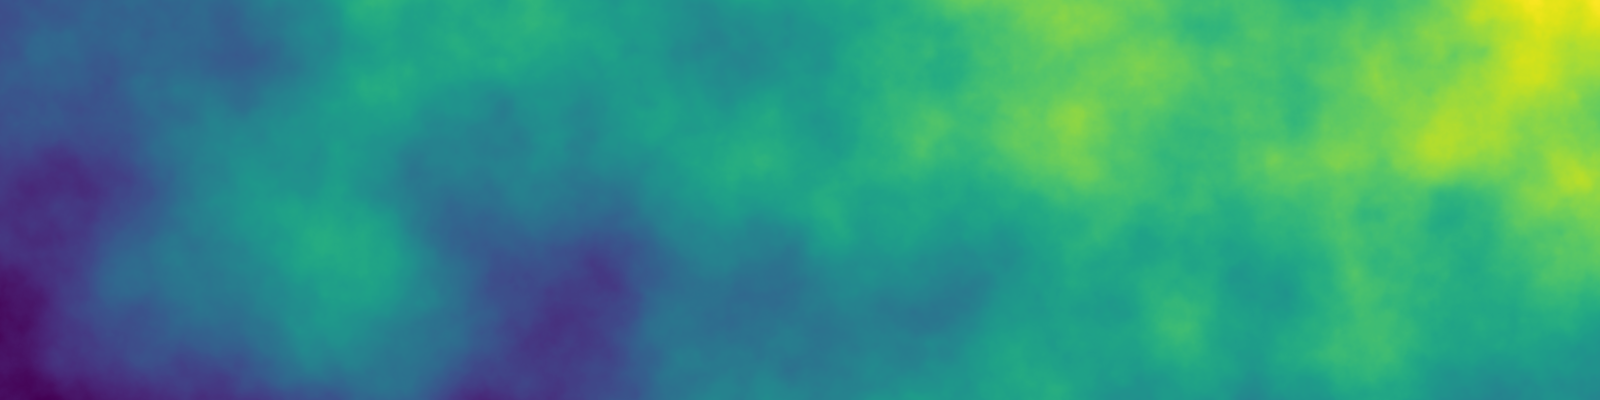
<figcaption aria-hidden="true">Fractal terrain</figcaption>
</figure>

## Visual Studio Code

Alternatively, you could run your computational notebook in an
integrated development environment. Follow these instructions, if you
would like to use Visual Studio Code. Install [Visual Studio
Code](https://code.visualstudio.com/download) for Windows. When prompted
during installation, add it to your path. The install the [WSL
Extension](https://marketplace.visualstudio.com/items?itemName=ms-vscode-remote.remote-wsl).
Start Visual Studio Code, open the Command Palette with
`Ctrl + Shift + P`, and connect to WSL. Open extensions pane with
`Ctrl + Shift + X` and install the [Python
Extension](https://marketplace.visualstudio.com/items?itemName=ms-python.python)
for your remote WSL connection. When prompted choose
`Install in WSL: Ubuntu`.

In Visual Studio Code’s explorer, browse to the directory in which you
plan to work. The first time you open a directory, it will be
restricted, so you must trust this workspace before you can run code.
When prompted whether you trust the authors of file in this folder,
choose yes. Now, create a new Jupyter notebook in this directory. For
this notebook, set the Python interpreter and notebook kernel to your
Conda environment. To do this, open the Command Palette with
`Ctrl + Shift + P`, run `Python: Select Interpreter`, and select your
environment named `grass`. Open the Command Palette again, run
`Notebook: Select Notebook Kernel`, and select your environment named
`grass`.

> **Setting up Visual Studio Code**
>
> More more information, see the official guide to [get started using
> Visual Studio Code with Windows Subsystem for
> Linux](https://learn.microsoft.com/en-us/windows/wsl/tutorials/wsl-vscode).

<span class="nocase">conda-forge community</span>. 2026. *Miniforge*. V.
26.3.2-0. Released. <https://conda-forge.org/download/>.